In [1]:
import sys
sys.path.append('/home/gridsan/tmackey/cdvae/scripts/XRD_CDVAE')
import importlib
import data_utils.RRUFF_utils
import data_utils.pv_utils
import data_utils.structure_utils
import viz_utils.viz
importlib.reload(data_utils.RRUFF_utils)
importlib.reload(data_utils.pv_utils)
importlib.reload(data_utils.structure_utils)
importlib.reload(viz_utils.viz)
from data_utils.RRUFF_utils import *
from data_utils.pv_utils import *
from data_utils.structure_utils import *
from viz_utils.viz import *

In [2]:
cif_dict_with_structures = torch.load("/home/gridsan/tmackey/cdvae/scripts/XRD_CDVAE/RRUFF/ckpt/amcsd/2024-03-22/cif_dict_with_pymatgen_structures.pt")

In [3]:
new_instance = RRUFF_data("xy_dir", "cif_dir", cif_dict = cif_dict_with_structures, label = "amcsd")

Reading in xy data...


100%|██████████| 4364/4364 [00:02<00:00, 1501.68it/s]
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/core/periodic_table.py:221: UserWarning: No Pauling electronegativity for Nh. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  warnings.warn(
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/core/periodic_table.py:221: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  warnings.warn(
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/core/periodic_table.py:221: UserWarning: No Pauling electronegativity for Nh. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  warnings.warn(
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymat

In [4]:
fulldf = all_match(new_instance, cif_dict_with_structures)

  2%|▏         | 4/177 [00:02<01:17,  2.22it/s]/home/gridsan/tmackey/cdvae/scripts/XRD_CDVAE/data_utils/pv_utils.py:149: RuntimeWarning: invalid value encountered in arcsin
  theta_2 = np.arcsin(lambda_2 / (2 * d))
  7%|▋         | 12/177 [00:06<01:28,  1.87it/s]/home/gridsan/tmackey/cdvae/scripts/XRD_CDVAE/data_utils/pv_utils.py:149: RuntimeWarning: invalid value encountered in arcsin
  theta_2 = np.arcsin(lambda_2 / (2 * d))
 31%|███       | 54/177 [01:34<01:43,  1.18it/s]/home/gridsan/tmackey/cdvae/scripts/XRD_CDVAE/data_utils/pv_utils.py:149: RuntimeWarning: invalid value encountered in arcsin
  theta_2 = np.arcsin(lambda_2 / (2 * d))
 37%|███▋      | 65/177 [01:45<01:48,  1.04it/s]/home/gridsan/tmackey/cdvae/scripts/XRD_CDVAE/data_utils/pv_utils.py:149: RuntimeWarning: invalid value encountered in arcsin
  theta_2 = np.arcsin(lambda_2 / (2 * d))
 51%|█████     | 90/177 [02:21<02:37,  1.82s/it]/home/gridsan/tmackey/cdvae/scripts/XRD_CDVAE/data_utils/pv_utils.py:149: RuntimeWarning:

In [2]:
fulldf = torch.load("noise_analysis_data/RRUFF_data_for_noise_analysis.pt")

In [3]:
chemicals_to_remove = ["Babingtonite",
                        "Lizardite",
                        "Delhayelite",
                        "Cechite",
                        "Spodumene",
                        "Paragonite",
                        "Chalcosiderite",
                        "Gold",
                        "Gyrolite",
                        "Miserite",
                        "Pentahydrite",
                        "Fluorophlogopite",
                        "Zirkelite",
                        "Larisaite",
                        "Cristobalite",
                        "Conichalcite",
                        "Jadeite",
                        "Chalcocite",
                        "Vayrynenite",
                        "Piemontite",
                        "Rhodonite",
                        "Nitratine",
                        "Nontronite",
                        "Zircon",
                        "Sampleite",
                        "Bernardevansite",
                        "Cryolite",
                        "Argentojarosite",
                        "Metavoltine",
                        "Gillespite",
                        "Buddingtonite",
                        "Haiweeite",
                        "Spinel",
                        "Tobermorite",
                        "Margarite",
                        "Zinc",
                        "Chlorartinite",
                        "Afghanite",
                        "Ferrowyllieite",
                        "Slavikite",
                        "Cymrite",
                        "Erythrite",
                        "Staurolite",
                        "Petalite",
                        "Tinzenite",
                       ]

In [5]:
#drop rows with names in chemicals_to_remove
fulldf = fulldf[~fulldf["names"].isin(chemicals_to_remove)]

In [6]:
fulldf

,xrd,names,spec,lps,filename,cif,material_id
0,"[[5.0, 25.0], [5.01, 18.0], [5.02, 41.0], [5.0...",Beryl,Powder,9.215400 0.000000 0.000000\n-4.607700 7.980771...,Beryl__R050347-1__Powder__Xray_Data_XY_RAW__15...,# generated using pymatgen\ndata_Cs0.16Na0.46L...,Beryl
0,"[[5.0, 0.0], [5.01, 6.252869], [5.02, 28.72253...",Triplite,Powder,11.525329 0.000000 -3.468730\n-0.000000 6.4646...,Triplite__R050226-1__Powder__Xray_Data_XY_Proc...,# generated using pymatgen\ndata_Ca0.4Mg2.8Mn3...,Triplite
0,"[[5.0, 31.0], [5.01, 28.0], [5.02, 25.0], [5.0...",Colemanite,Powder,8.191522 0.000000 -3.004968\n-0.000000 11.2550...,Colemanite__R050331-1__Powder__Xray_Data_XY_RA...,# generated using pymatgen\ndata_Ca3.76B12H20O...,Colemanite
0,"[[5.0, 46.0], [5.01, 41.0], [5.02, 33.0], [5.0...",Norbergite,Powder,4.711000 0.000000 0.000000\n-0.000000 10.27280...,Norbergite__R050280-1__Powder__Xray_Data_XY_RA...,# generated using pymatgen\ndata_Mg11.916Fe0.0...,Norbergite
0,"[[5.0, 0.0], [5.01, 22.56316], [5.02, 10.66376...",Caryochroite,Powder,None,Caryochroite__R070008-1__Powder__Xray_Data_XY_...,# generated using pymatgen\ndata_K0.52Na2.36Sr...,Caryochroite
...,...,...,...,...,...,...,...
0,"[[5.0, 0.0], [5.01, 5.269], [5.02, 32.808], [5...",Ilvaite,Powder,12.997672 0.000000 -0.092330\n-0.000000 8.7860...,Ilvaite__R050040-1__Powder__Xray_Data_XY_Proce...,# generated using pymatgen\ndata_Ca4Mn0.3Fe11....,Ilvaite
0,"[[5.0, 0.0], [5.01, 12.35646], [5.02, 5.814178...",Hydroniumjarosite,Powder,7.315300 0.000000 0.000000\n-3.657650 6.335236...,Hydroniumjarosite__R060402-1__Powder__Xray_Dat...,# generated using pymatgen\ndata_Na0.49Fe3H6.5...,Hydroniumjarosite
0,"[[5.0, 0.0], [5.01, 6.56892], [5.02, 7.2621], ...",Gehlenite,Powder,7.739800 0.000000 0.000000\n-0.000000 7.739800...,Gehlenite__R060841-1__Powder__Xray_Data_XY_Pro...,# generated using pymatgen\ndata_Ca4Mg0.1Al3.8...,Gehlenite
0,"[[5.0, 25.0], [5.01, 23.0], [5.02, 17.0], [5.0...",Perovskite,Powder,5.398000 0.000000 0.000000\n-0.000000 5.463700...,Perovskite__R050456-1__Powder__Xray_Data_XY_RA...,# generated using pymatgen\ndata_CsRbCo2F6\n_s...,Perovskite


In [ ]:
torch.save(fulldf, "noise_analysis_data/RRUFF_data_for_noise_analysis_filtered.pt")

Goal: make function that Eric can just run the function to see all of the compounds. Then, if there isn't a good match, he can pinpoint where the eror is and see all the other options & their indices. It would also be good if there was a way by which he can acess the underlying compound and xy files as well (he could do this by just ls-ing in the appropriate directories). 

Ignore code below, will become relevant after we pick the compounds

In [463]:
#save df_4 to a csv file in /home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd
df_4.to_csv("/home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/df4_new.csv", index=False)

In [469]:
#make pv_dict_3 by looping through the keys in pv_dict_2 and only keeping the ones that are in df_4
pv_dict_3 = {}
for key in pv_dict_2.keys():
    if key in df_4['material_id'].values:
        pv_dict_3[key] = pv_dict_2[key]

In [472]:
#only keep the second column of the pv_dict_3 values
for key in pv_dict_3.keys():
    pv_dict_3[key] = pv_dict_3[key][0][:,1]

In [476]:
#unsqueeze at the 0th dimension
for key in pv_dict_3.keys():
    pv_dict_3[key] = pv_dict_3[key].unsqueeze(0)

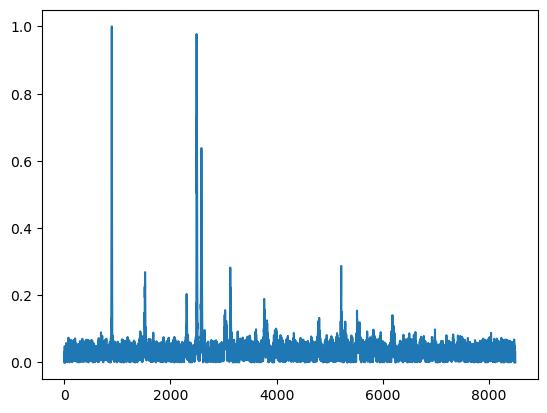

In [478]:
#plot the first value in pv_dict_3 to make sure it looks right
plt.plot(pv_dict_3[df_4['material_id'].iloc[1]][0])

In [480]:
torch.save(pv_dict_3, "/home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/test_pv_xrd_dict_3.pt")

In [129]:
#load in test_pv_xrd.pt
pv_dict_4 = torch.load("/home/gridsan/tmackey/cdvae/data/RRUFF_data_test_only_using_amcsd/test_pv_xrd.pt")

In [ ]:
for index in tqdm(range(len(list(pv_dict_4.keys())))): 
    if torch.sum(pv_dict_4['Brucite'][0][:5] == pv_dict_4['Brucite'][0][5:10]) == 5: 
        print("simulated xrd, ", list(pv_dict_4.keys())[index], " is all zeros")